In [28]:
## Load muckrakers

import csv
import pandas as pd
import matplotlib.pyplot as plt




In [14]:
## Read in the information
my_df = pd.read_csv('Donors_Data.csv', delimiter=',', header = 0)

## See if it worked

print(my_df.head)


<bound method NDFrame.head of       Row Id  Row Id.  zipconvert_2  zipconvert_3  zipconvert_4  zipconvert_5  \
0          1       17             0             1             0             0   
1          2       25             1             0             0             0   
2          3       29             0             0             0             1   
3          4       38             0             0             0             1   
4          5       40             0             1             0             0   
...      ...      ...           ...           ...           ...           ...   
3115    3116    23256             0             0             0             1   
3116    3117    23258             0             1             0             0   
3117    3118    23261             0             0             0             1   
3118    3119    23265             0             0             0             1   
3119    3120    23293             0             0             1             0  

In [15]:
## Print a list of current column names

print(my_df.columns.tolist())

['Row Id', 'Row Id.', 'zipconvert_2', 'zipconvert_3', 'zipconvert_4', 'zipconvert_5', 'homeowner dummy', 'NUMCHLD', 'INCOME', 'gender dummy', 'WEALTH', 'HV', 'Icmed', 'Icavg', 'IC15', 'NUMPROM', 'RAMNTALL', 'MAXRAMNT', 'LASTGIFT', 'totalmonths', 'TIMELAG', 'AVGGIFT', 'TARGET_B', 'TARGET_D']


In [19]:
# Subset specific columns and rename them
donations_df = my_df[['Row Id', 'LASTGIFT', 'AVGGIFT']].rename(columns={'Row Id': 'donor', 'LASTGIFT': 'last_donation','AVGGIFT' : 'avg_donation' })
donations_df = pd.DataFrame(donations_df, columns=['donor','last_donation','avg_donation'])

#This column will tell me the difference between the last donation and the average.

donations_df['d_change'] = donations_df['last_donation']-donations_df['avg_donation']


# Display the new DataFrame
print(donations_df)

      donor  last_donation  avg_donation  d_change
0         1            5.0      4.857143  0.142857
1         2           12.0      9.400000  2.600000
2         3            5.0      4.285714  0.714286
3         4            8.0      7.080000  0.920000
4         5           11.0      7.666667  3.333333
...     ...            ...           ...       ...
3115   3116            4.0      7.500000 -3.500000
3116   3117           30.0     26.500000  3.500000
3117   3118           20.0     11.157895  8.842105
3118   3119           20.0     20.000000  0.000000
3119   3120            9.0      9.250000 -0.250000

[3120 rows x 4 columns]


In [20]:
## This sets the index to donor and should allow me to run count operations on the subset. 

donations_df = donations_df.set_index('donor')

donations_df

,last_donation,avg_donation,d_change
donor,,,
1,5.0,4.857143,0.142857
2,12.0,9.400000,2.600000
3,5.0,4.285714,0.714286
4,8.0,7.080000,0.920000
5,11.0,7.666667,3.333333
...,...,...,...
3116,4.0,7.500000,-3.500000
3117,30.0,26.500000,3.500000
3118,20.0,11.157895,8.842105


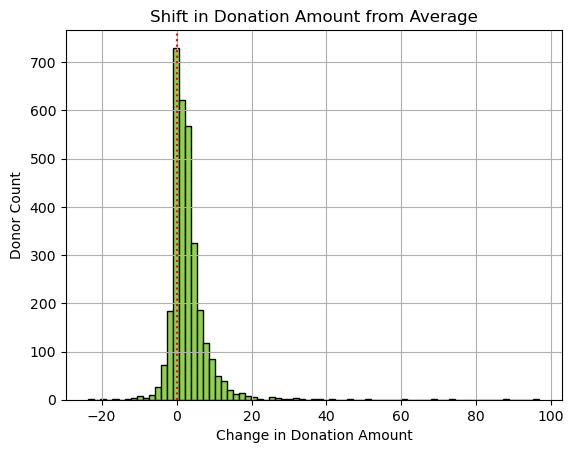

In [34]:
donations_df['d_change'].hist(bins = 75, color= '#92cf51', edgecolor = 'black')
plt.xlabel('Change in Donation Amount')
plt.ylabel('Donor Count')
plt.title('Shift in Donation Amount from Average')

plt.axvline(x=0, color='red', linestyle=':', label='0')

In [44]:
donor_report =  my_df[['Row Id','WEALTH', 'LASTGIFT', 'AVGGIFT','TIMELAG']].rename(columns={'Row Id': 'donor', 'WEALTH' : 'wealth_cat','LASTGIFT': 'last_donation','AVGGIFT' : 'avg_donation','TIMELAG' : 'time_bw_donation' })
donor_report = pd.DataFrame(donor_report, columns=['wealth_cat','last_donation','avg_donation','time_bw_donation'])
donor_report['d_change'] = donor_report['last_donation']-donor_report['avg_donation']
donor_report = donor_report.set_index('wealth_cat')

donor_report


,last_donation,avg_donation,time_bw_donation,d_change
wealth_cat,,,,
9,5.0,4.857143,3,0.142857
7,12.0,9.400000,6,2.600000
8,5.0,4.285714,7,0.714286
4,8.0,7.080000,3,0.920000
8,11.0,7.666667,6,3.333333
...,...,...,...,...
8,4.0,7.500000,5,-3.500000
8,30.0,26.500000,9,3.500000
7,20.0,11.157895,3,8.842105


In [45]:
## Generate a report that pivots the wealth category, and analyzes it against the average change in donation for that category based on 
## lag time since their last donation. 

report = pd.pivot_table(donor_report, values='d_change', index=['wealth_cat'],
                       columns=['time_bw_donation'], aggfunc="mean")
report

time_bw_donation,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,44,48,62,77
wealth_cat,,,,,,,,,,,,,,,,,,,,,
0,3.709677,0.712500,1.970540,3.123149,4.842399,1.767470,2.860915,1.017810,3.558267,3.868036,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.641803,1.926712,-0.098394,3.767905,1.376719,3.805737,2.746978,4.439439,2.757570,0.666616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,NaN,NaN
2,3.055274,3.090675,2.513547,3.735516,1.265708,0.829445,1.600668,2.033788,10.702373,5.298203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.281250,6.846694,2.878414,4.463785,1.469188,2.656375,1.458691,3.716393,4.302195,1.033708,...,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,12.170732,NaN
4,6.734127,4.763397,4.806157,3.123219,7.856888,2.554803,0.606834,2.948429,3.818992,3.535989,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.352941,1.632462,1.501974,2.363419,4.377607,1.404195,4.693124,1.766665,1.213248,5.727551,...,NaN,-1.928571,NaN,NaN,NaN,2.157895,NaN,NaN,NaN,NaN
6,0.757112,0.404163,2.598751,4.744976,1.283744,2.882083,5.451985,3.670102,2.646550,3.093904,...,NaN,NaN,-4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3.471941,4.416809,3.448005,2.468515,4.274175,4.431208,3.791903,3.800822,1.150138,3.855279,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.408313,1.258730,2.267034,2.235497,2.175403,1.472379,3.604661,2.584717,2.146259,3.773082,...,1.615625,NaN,NaN,NaN,1.533333,NaN,-2.142857,NaN,NaN,6.125


In [46]:
file_path = 'donation_change_by_lag.csv'
report.to_csv(file_path, index=False)